# Generative AI untuk Text

In [1]:
import os
import time
import math

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device yang digunakan:", device)

Device yang digunakan: cpu


In [2]:
text_path = "dataset_text/data.txt"

with open(text_path, "r", encoding="utf-8") as file:
    text = file.read().lower()

print("Jumlah karakter dalam dataset:", len(text))


Jumlah karakter dalam dataset: 1997757


link url dataset yang digunakan: https://www.kaggle.com/datasets/agustrinaldo/nlp-emotion-text-dataset-bahasa-indonesia

In [3]:
max_chars = 50000
text = text[:max_chars]

print("Jumlah karakter yang digunakan:", len(text))
print("\nContoh isi dataset:")
print(text[:500])

if len(text) == 0:
    raise ValueError("Dataset kosong. Periksa isi file dataset_text/data.txt")

lines = text.splitlines()

print("\nJumlah baris/kalimat:", len(lines))
print("Contoh 5 baris pertama:")

for line in lines[:5]:
    print("-", line)

Jumlah karakter yang digunakan: 50000

Contoh isi dataset:
saya tidak merasa terhina;kesedihan
saya bisa berubah dari merasa sangat putus asa menjadi sangat berharap hanya dari berada di sekitar seseorang yang peduli dan terjaga;kesedihan
saya mengambil waktu sebentar untuk memposting saya merasa serakah salah;kemarahan
saya pernah merasa nostalgia tentang perapian saya akan tahu bahwa itu masih di properti;cinta
saya merasa kesal;kemarahan
saya merasa sedikit terbebani akhir-akhir ini tidak yakin mengapa itu;kesedihan
saya telah mengonsumsi atau miligr

Jumlah baris/kalimat: 389
Contoh 5 baris pertama:
- saya tidak merasa terhina;kesedihan
- saya bisa berubah dari merasa sangat putus asa menjadi sangat berharap hanya dari berada di sekitar seseorang yang peduli dan terjaga;kesedihan
- saya mengambil waktu sebentar untuk memposting saya merasa serakah salah;kemarahan
- saya pernah merasa nostalgia tentang perapian saya akan tahu bahwa itu masih di properti;cinta
- saya merasa kesal;kem

### Tokenization Character-level

In [4]:
chars = sorted(list(set(text)))

char_to_idx = {char: idx for idx, char in enumerate(chars)}
idx_to_char = {idx: char for idx, char in enumerate(chars)}

vocab_size = len(chars)

print("\nJumlah karakter unik:", vocab_size)
print("Daftar karakter unik:")
print(chars)

encoded_text = [char_to_idx[char] for char in text]

print("\nContoh encoded text:")
print(encoded_text[:100])


Jumlah karakter unik: 32
Daftar karakter unik:
['\n', ' ', ',', '-', ';', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '\u200b']

Contoh encoded text:
[23, 5, 29, 5, 1, 24, 13, 8, 5, 15, 1, 17, 9, 22, 5, 23, 5, 1, 24, 9, 22, 12, 13, 18, 5, 4, 15, 9, 23, 9, 8, 13, 12, 5, 18, 0, 23, 5, 29, 5, 1, 6, 13, 23, 5, 1, 6, 9, 22, 25, 6, 5, 12, 1, 8, 5, 22, 13, 1, 17, 9, 22, 5, 23, 5, 1, 23, 5, 18, 11, 5, 24, 1, 20, 25, 24, 25, 23, 1, 5, 23, 5, 1, 17, 9, 18, 14, 5, 8, 13, 1, 23, 5, 18, 11, 5, 24, 1, 6, 9]


### Tokenization Character-Level

Pada character-level text generation, setiap karakter dianggap sebagai token. Contohnya:

```text
"saya" → ["s", "a", "y", "a"]

### Dataset Sequence

In [5]:
class TextDataset(Dataset):
    def __init__(self, encoded_text, sequence_length):
        self.encoded_text = encoded_text
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.encoded_text) - self.sequence_length

    def __getitem__(self, idx):
        input_seq = self.encoded_text[idx : idx + self.sequence_length]
        target_seq = self.encoded_text[idx + 1 : idx + self.sequence_length + 1]

        input_seq = torch.tensor(input_seq, dtype=torch.long)
        target_seq = torch.tensor(target_seq, dtype=torch.long)

        return input_seq, target_seq


### Data Loader

In [6]:
sequence_length = 50
batch_size = 128

dataset_text = TextDataset(encoded_text, sequence_length)

train_loader_text = DataLoader(
    dataset_text,
    batch_size=batch_size,
    shuffle=True
)

print("\nJumlah sequence training:", len(dataset_text))


Jumlah sequence training: 49950


### menghitung parameter

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### MODEL LSTM TEXT GENERATOR

In [8]:
class LSTMTextGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1):
        super(LSTMTextGenerator, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Mengubah index karakter menjadi vector embedding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )

        # LSTM mempelajari pola urutan karakter
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully connected layer untuk memprediksi karakter berikutnya
        self.fc = nn.Linear(
            in_features=hidden_dim,
            out_features=vocab_size
        )

    def forward(self, x, hidden=None):
        x = self.embedding(x)

        output, hidden = self.lstm(x, hidden)

        output = self.fc(output)

        return output, hidden

Text generation dilakukan dengan memprediksi token atau karakter berikutnya berdasarkan token-token sebelumnya.

Rumus text generation adalah:

$$
p(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} p(x_t | x_1, x_2, ..., x_{t-1})
$$

Keterangan:

- $x_t$ adalah token atau karakter pada posisi ke-$t$.
- $x_1, x_2, ..., x_{t-1}$ adalah token-token sebelumnya.
- $p(x_t | x_1, x_2, ..., x_{t-1})$ adalah probabilitas token berikutnya berdasarkan konteks sebelumnya.

Pada implementasi ini digunakan dua model, yaitu LSTM Text Generator dan Transformer Text Generator.

LSTM memproses karakter secara berurutan menggunakan:

```python
LSTMTextGenerator(nn.Module)

### Model Transformer text generator

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, embedding_dim, max_length=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_length, embedding_dim)

        position = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2).float()
            * (-math.log(10000.0) / embedding_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        sequence_length = x.size(1)

        x = x + self.pe[:, :sequence_length, :]

        return x
    
class TransformerTextGenerator(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=64,
        num_heads=4,
        hidden_dim=128,
        num_layers=1,
        dropout=0.1,
        max_length=5000
    ):
        super(TransformerTextGenerator, self).__init__()

        self.embedding_dim = embedding_dim

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim
        )

        self.positional_encoding = PositionalEncoding(
            embedding_dim=embedding_dim,
            max_length=max_length
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(
            in_features=embedding_dim,
            out_features=vocab_size
        )

    def generate_square_subsequent_mask(self, size):
        mask = torch.triu(
            torch.ones(size, size),
            diagonal=1
        ).bool()

        return mask.to(device)

    def forward(self, x):
        sequence_length = x.size(1)

        x = self.embedding(x) * math.sqrt(self.embedding_dim)

        x = self.positional_encoding(x)

        mask = self.generate_square_subsequent_mask(sequence_length)

        output = self.transformer(x, mask=mask)

        output = self.fc(output)

        return output

### Rumus Self-Attention Transformer

Transformer menggunakan mekanisme self-attention untuk melihat hubungan antar token dalam sequence.

Rumus self-attention adalah:

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Keterangan:

- $Q$ adalah query.
- $K$ adalah key.
- $V$ adalah value.
- $d_k$ adalah dimensi key.
- $softmax$ mengubah skor attention menjadi bobot probabilitas.

Pada kode PyTorch, mekanisme ini diwakili oleh:

```python
TransformerTextGenerator(nn.Module)

In [10]:
embedding_dim = 64
hidden_dim = 128
num_layers = 1
num_heads = 4

model_lstm = LSTMTextGenerator(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(device)

model_transformer = TransformerTextGenerator(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_heads=num_heads,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(device)

print("\nModel LSTM:")
print(model_lstm)
print("Jumlah parameter LSTM:", count_parameters(model_lstm))

print("\nModel Transformer:")
print(model_transformer)
print("Jumlah parameter Transformer:", count_parameters(model_transformer))


Model LSTM:
LSTMTextGenerator(
  (embedding): Embedding(32, 64)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=32, bias=True)
)
Jumlah parameter LSTM: 105504

Model Transformer:
TransformerTextGenerator(
  (embedding): Embedding(32, 64)
  (positional_encoding): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=Fals

### Loss Function dan Optimizer

In [11]:
criterion_lstm = nn.CrossEntropyLoss()
criterion_transformer = nn.CrossEntropyLoss()

optimizer_lstm = optim.Adam(
    model_lstm.parameters(),
    lr=0.001
)

optimizer_transformer = optim.Adam(
    model_transformer.parameters(),
    lr=0.001
)

### Cross Entropy Loss untuk Text Generation

Loss yang digunakan pada text generation adalah Cross Entropy Loss. Loss ini cocok karena model harus memilih satu karakter target dari seluruh vocabulary karakter.

Rumus Cross Entropy Loss adalah:

$$
L = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)
$$

Keterangan:

- $y_i$ adalah token target sebenarnya.
- $\hat{y}_i$ adalah probabilitas token hasil prediksi model.
- $N$ adalah jumlah token atau class dalam vocabulary.

Pada kode PyTorch, rumus ini diimplementasikan dengan:

```python
criterion_lstm = nn.CrossEntropyLoss()
criterion_transformer = nn.CrossEntropyLoss()

### Training Model

In [12]:
num_epochs_lstm = 5

train_losses_lstm = []

start = time.time()

for epoch in range(num_epochs_lstm):
    model_lstm.train()

    total_loss = 0

    for input_seq, target_seq in train_loader_text:
        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        optimizer_lstm.zero_grad()

        output, hidden = model_lstm(input_seq)

        # output shape     : [batch_size, sequence_length, vocab_size]
        # target_seq shape : [batch_size, sequence_length]
        # CrossEntropyLoss membutuhkan:
        # output     : [batch_size * sequence_length, vocab_size]
        # target_seq : [batch_size * sequence_length]

        output = output.reshape(-1, vocab_size)
        target_seq = target_seq.reshape(-1)

        loss = criterion_lstm(output, target_seq)

        loss.backward()

        optimizer_lstm.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_text)
    train_losses_lstm.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_lstm}], LSTM Loss: {avg_loss:.4f}")

end = time.time()

training_time_lstm = end - start

print("Training time LSTM:", training_time_lstm, "seconds")

Epoch [1/5], LSTM Loss: 1.7024
Epoch [2/5], LSTM Loss: 1.1725
Epoch [3/5], LSTM Loss: 1.0227
Epoch [4/5], LSTM Loss: 0.9218
Epoch [5/5], LSTM Loss: 0.8405
Training time LSTM: 37.13075590133667 seconds


In [13]:
num_epochs_transformer = 5

train_losses_transformer = []

start = time.time()

for epoch in range(num_epochs_transformer):
    model_transformer.train()

    total_loss = 0

    for input_seq, target_seq in train_loader_text:
        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        optimizer_transformer.zero_grad()

        output = model_transformer(input_seq)

        output = output.reshape(-1, vocab_size)
        target_seq = target_seq.reshape(-1)

        loss = criterion_transformer(output, target_seq)

        loss.backward()

        optimizer_transformer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_text)
    train_losses_transformer.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_transformer}], Transformer Loss: {avg_loss:.4f}")

end = time.time()

training_time_transformer = end - start

print("Training time Transformer:", training_time_transformer, "seconds")

Epoch [1/5], Transformer Loss: 2.1071
Epoch [2/5], Transformer Loss: 1.9937
Epoch [3/5], Transformer Loss: 1.9694
Epoch [4/5], Transformer Loss: 1.9504
Epoch [5/5], Transformer Loss: 1.9269
Training time Transformer: 34.991105794906616 seconds



### Training LSTM Text Generator

Pada proses training LSTM, input sequence dimasukkan ke model untuk menghasilkan prediksi karakter pada setiap posisi sequence.

Alur training LSTM adalah:

**Input sequence → Embedding → LSTM → Fully Connected Layer → Prediksi karakter → Hitung loss → Backpropagation**

Pada kode, proses forward dilakukan dengan:

```python
output, hidden = model_lstm(input_seq)

Output model kemudian diubah bentuknya agar sesuai dengan Cross Entropy Loss pada kode : 
output = output.reshape(-1, vocab_size)
target_seq = target_seq.reshape(-1)

Setelah loss dihitung, dilakukan backpropagation dan update parameter:
loss.backward()
optimizer_lstm.step()

dimana Jika loss menurun, berarti model semakin baik dalam memprediksi karakter berikutnya.

### Grafik Training Loss

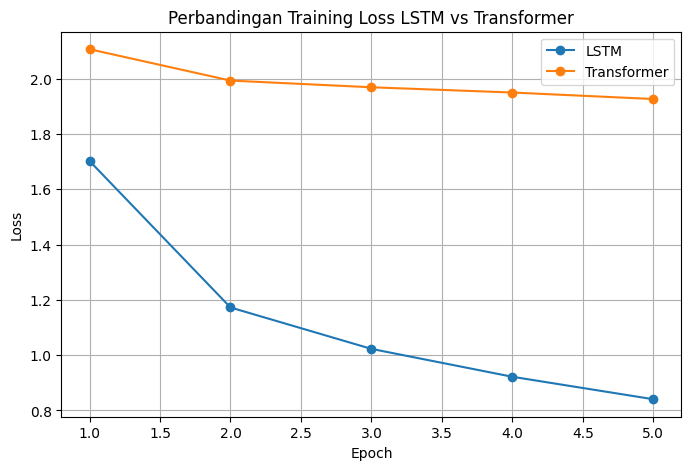

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses_lstm) + 1),
    train_losses_lstm,
    marker="o",
    label="LSTM"
)

plt.plot(
    range(1, len(train_losses_transformer) + 1),
    train_losses_transformer,
    marker="o",
    label="Transformer"
)

plt.title("Perbandingan Training Loss LSTM vs Transformer")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
def generate_text_lstm(model, prompt, length=300, temperature=0.8):
    model.eval()

    generated_text = prompt.lower()

    input_indices = [
        char_to_idx[char]
        for char in generated_text
        if char in char_to_idx
    ]

    if len(input_indices) == 0:
        return "Prompt tidak memiliki karakter yang ada di vocabulary dataset."

    input_tensor = torch.tensor(
        input_indices,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    hidden = None

    with torch.no_grad():
        for _ in range(length):
            output, hidden = model(input_tensor, hidden)

            last_output = output[:, -1, :]

            last_output = last_output / temperature

            probabilities = torch.softmax(last_output, dim=-1)

            next_char_idx = torch.multinomial(
                probabilities,
                num_samples=1
            ).item()

            next_char = idx_to_char[next_char_idx]

            generated_text += next_char

            input_tensor = torch.tensor(
                [[next_char_idx]],
                dtype=torch.long
            ).to(device)

    return generated_text



### Generate Text dari Prompt

In [16]:
def generate_text_transformer(model, prompt, length=300, temperature=0.8):
    model.eval()

    generated_text = prompt.lower()

    input_indices = [
        char_to_idx[char]
        for char in generated_text
        if char in char_to_idx
    ]

    if len(input_indices) == 0:
        return "Prompt tidak memiliki karakter yang ada di vocabulary dataset."

    with torch.no_grad():
        for _ in range(length):
            input_tensor = torch.tensor(
                input_indices,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            output = model(input_tensor)

            last_output = output[:, -1, :]

            last_output = last_output / temperature

            probabilities = torch.softmax(last_output, dim=-1)

            next_char_idx = torch.multinomial(
                probabilities,
                num_samples=1
            ).item()

            next_char = idx_to_char[next_char_idx]

            generated_text += next_char

            input_indices.append(next_char_idx)

            # Batasi panjang konteks agar proses generate tidak terlalu berat
            if len(input_indices) > sequence_length:
                input_indices = input_indices[-sequence_length:]

    return generated_text

### contoh prompt dari hasil generasi

In [17]:
prompt = "saya merasa"

generated_lstm = generate_text_lstm(
    model=model_lstm,
    prompt=prompt,
    length=300,
    temperature=0.8
)

generated_transformer = generate_text_transformer(
    model=model_transformer,
    prompt=prompt,
    length=300,
    temperature=0.8
)

print("=" * 80)
print("Prompt:")
print(prompt)

print("\nHasil Generate LSTM:")
print(generated_lstm)

print("\nHasil Generate Transformer:")
print(generated_transformer)

Prompt:
saya merasa

Hasil Generate LSTM:
saya merasa rentar bahwa saya merasa pus;kesedihan
saya mulai melihat tapi ada yang bisa bungkannya untuk benar-bentan ke dalam risi saya sedikit tidak dihargu;kesedihan
saya menghambatan yang saya maks yang sendiri dan mulai merasa sangat pagi saya anda ingin gembra dan kerasa saya benar-benar kesepian dan ke

Hasil Generate Transformer:
saya merasa a prlaya sayaka sangem pan mperi tang inanyaterikameran i emasa payang sat sayaya men
sa ka sasebuahikanaya rsa in sa men kesasayan sa ka t yasa sanga melakerahu dingar yasaya ta ra t sen
saya mera di saya kah sa k mun men meralahayanga tas rayaya tu sasebemenin jituh angan dian apeta lutan
saya gk


### contoh output

In [18]:
prompts = [
    "saya merasa",
    "hari ini",
    "aku ingin",
    "perasaan saya",
    "ketika melihat"
]

for prompt in prompts:
    generated_lstm = generate_text_lstm(
        model=model_lstm,
        prompt=prompt,
        length=200,
        temperature=0.8
    )

    generated_transformer = generate_text_transformer(
        model=model_transformer,
        prompt=prompt,
        length=200,
        temperature=0.8
    )

    print("=" * 80)
    print("Prompt:", prompt)

    print("\nGenerated Text LSTM:")
    print(generated_lstm)

    print("\nGenerated Text Transformer:")
    print(generated_transformer)


Prompt: saya merasa

Generated Text LSTM:
saya merasa punya dengan senang adalah memukin kesedihan saya terbang untuk peluar manah saya ada;kegembiraan
saya merasa meriah itu beruntung tetapi ada hepan pengonan damarkali dalam merasa sangat karena saya 

Generated Text Transformer:
saya merasasa a tidatiti satilangandayalun tang da k mpen mikan
sa be san di aya hu ba an daseri-beng pahantangan
sayayayaya pekalan mema;kapukemelu membi meradapah i din kera asaya bengerkuasa tung mengang mp k
Prompt: hari ini

Generated Text LSTM:
hari ini;cinta
saya bertanya-tanya apakah kata-kata karena saya merasa seperti saya merasa kelol dipakai seperti saya sendiri dan katakan saya melihat bagu atau adalah pendebia sangat terlebuhkan tua merasa t

Generated Text Transformer:
hari ini kia man an
sakeraya pang sang sik merira saya ftusa bengpasayaya
sa mengang sayarok sa sayang a sa meh berteraiaya smela era uka pran
sayayat muantu mementa sarayayasa sa sa sa sa da mi ken seratan s
Prompt: aku ingin



### Komparasi temperature

In [19]:
prompt = "saya merasa"

temperatures = [0.5, 0.8, 1.2]

for temp in temperatures:
    generated_lstm = generate_text_lstm(
        model=model_lstm,
        prompt=prompt,
        length=250,
        temperature=temp
    )

    generated_transformer = generate_text_transformer(
        model=model_transformer,
        prompt=prompt,
        length=250,
        temperature=temp
    )

    print("=" * 80)
    print(f"Temperature: {temp}")

    print("\nLSTM:")
    print(generated_lstm)

    print("\nTransformer:")
    print(generated_transformer)


Temperature: 0.5

LSTM:
saya merasa puas dan merasa banggu;kegembiraan
saya merasa seperti bagi saya dan merasa ingin merasa seperti saya sedang mendapatkan saat saya merasa sangat kecil akan merasa sangat mendapatkan saya mendapatkan sini;kemarahan
saya merasa sangat lesukan dia tida

Transformer:
saya merasa dang ding saya pan meratenanyak di pan yang meng sat daya da seng sa saya da tu merasan man saya sa sa sa mudaya sa mera sa siha mera ka sung merang dangangadatanti daran saya a men sa da men sen mberaya berang beran saya sa sayan da dia da meran ma
Temperature: 0.8

LSTM:
saya merasa mengintik saya di pluchi di luar luar biasanya sangat setiap anak bayi jurang tangan dan mencoba membutuhkan dan ingin merasa bangun dan semua hal-hal daftar mudih dan memiliki pelesih dari merasa seperti saya merasa bahwa dia merindukan dia sering 

Transformer:
saya merasa sa pameraler anatantasan bel saaya mbekik;kerasa mbu perantangeri sangengedira sembeberemba da laya hang ba man sayayada ba me

In [20]:
print("\nTabel Perbandingan LSTM vs Transformer")
print("-" * 100)
print(f"{'Model':<20} {'Final Loss':<20} {'Training Time (s)':<20} {'Jumlah Parameter':<20}")
print("-" * 100)

print(
    f"{'LSTM':<20} "
    f"{train_losses_lstm[-1]:<20.4f} "
    f"{training_time_lstm:<20.2f} "
    f"{count_parameters(model_lstm):<20}"
)

print(
    f"{'Transformer':<20} "
    f"{train_losses_transformer[-1]:<20.4f} "
    f"{training_time_transformer:<20.2f} "
    f"{count_parameters(model_transformer):<20}"
)

print("-" * 100)


Tabel Perbandingan LSTM vs Transformer
----------------------------------------------------------------------------------------------------
Model                Final Loss           Training Time (s)    Jumlah Parameter    
----------------------------------------------------------------------------------------------------
LSTM                 0.8405               37.13                105504              
Transformer          1.9269               34.99                37600               
----------------------------------------------------------------------------------------------------



### Eksperimen SEQUENCE LENGTH

In [21]:
def train_lstm_sequence_experiment(sequence_length_exp, num_epochs=3):
    print("=" * 80)
    print(f"Training LSTM dengan sequence_length = {sequence_length_exp}")
    print("=" * 80)

    dataset_exp = TextDataset(encoded_text, sequence_length_exp)

    train_loader_exp = DataLoader(
        dataset_exp,
        batch_size=batch_size,
        shuffle=True
    )

    model_exp = LSTMTextGenerator(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers
    ).to(device)

    criterion_exp = nn.CrossEntropyLoss()

    optimizer_exp = optim.Adam(
        model_exp.parameters(),
        lr=0.001
    )

    losses_exp = []

    start = time.time()

    for epoch in range(num_epochs):
        model_exp.train()

        total_loss = 0

        for input_seq, target_seq in train_loader_exp:
            input_seq = input_seq.to(device)
            target_seq = target_seq.to(device)

            optimizer_exp.zero_grad()

            output, hidden = model_exp(input_seq)

            output = output.reshape(-1, vocab_size)
            target_seq = target_seq.reshape(-1)

            loss = criterion_exp(output, target_seq)

            loss.backward()

            optimizer_exp.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader_exp)
        losses_exp.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

    end = time.time()

    training_time_exp = end - start

    print("Training time:", training_time_exp, "seconds")

    return model_exp, losses_exp, training_time_exp


sequence_lengths = [30, 50, 80]

num_epochs_sequence_exp = 3

sequence_results = {}

for seq_len in sequence_lengths:
    model_exp, losses_exp, training_time_exp = train_lstm_sequence_experiment(
        sequence_length_exp=seq_len,
        num_epochs=num_epochs_sequence_exp
    )

    sequence_results[seq_len] = {
        "model": model_exp,
        "losses": losses_exp,
        "training_time": training_time_exp
    }

Training LSTM dengan sequence_length = 30


Epoch [1/3], Loss: 1.7669
Epoch [2/3], Loss: 1.2564
Epoch [3/3], Loss: 1.1106
Training time: 14.100358963012695 seconds
Training LSTM dengan sequence_length = 50
Epoch [1/3], Loss: 1.7190
Epoch [2/3], Loss: 1.1885
Epoch [3/3], Loss: 1.0360
Training time: 24.94971489906311 seconds
Training LSTM dengan sequence_length = 80
Epoch [1/3], Loss: 1.6971
Epoch [2/3], Loss: 1.1443
Epoch [3/3], Loss: 0.9768
Training time: 38.2537100315094 seconds


### GRAFIK LOSS EKSPERIMEN SEQUENCE LENGTH

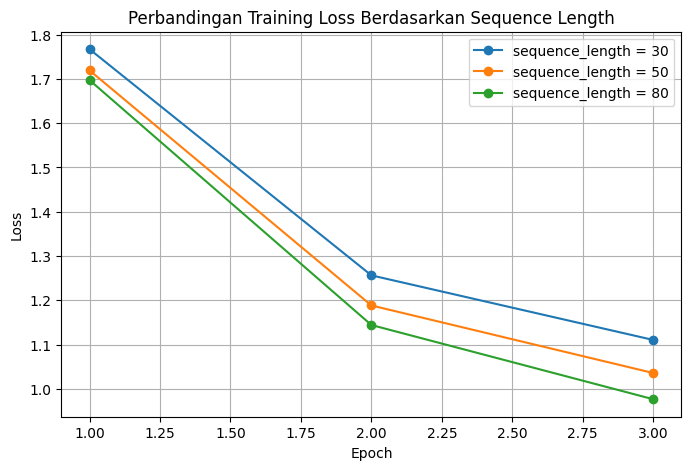

In [22]:
plt.figure(figsize=(8, 5))

for seq_len in sequence_lengths:
    losses = sequence_results[seq_len]["losses"]

    plt.plot(
        range(1, num_epochs_sequence_exp + 1),
        losses,
        marker="o",
        label=f"sequence_length = {seq_len}"
    )

plt.title("Perbandingan Training Loss Berdasarkan Sequence Length")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### OUTPUT GENERATED TEXT BERDASARKAN SEQUENCE LENGTH

In [23]:
prompt = "saya merasa"

for seq_len in sequence_lengths:
    model_exp = sequence_results[seq_len]["model"]

    generated = generate_text_lstm(
        model=model_exp,
        prompt=prompt,
        length=250,
        temperature=0.8
    )

    print("=" * 80)
    print(f"Sequence Length: {seq_len}")
    print(generated)

Sequence Length: 30
saya merasa tidak ketika itu menjadi ketika saya akan merasa semua beberapa kata-kata ketika saya merasa punakan;kesedihan
saya merasa tidak pergi ke telah menjadi lagi saya merasa sebuah ketika saya membentu mengengaraan perja dan ke dalam ini saya menguhan pa
Sequence Length: 50
saya merasa sangat karena saya merasa perusang akhir-baik saya membutuhkan di mana saya dapat meluji saya tidak menenanggan catus banyak hal di gebel dan menukin pegaris untuk mengambah atasa saya seseperti saya lebih di masi mendalaingya sedikit diberikan deng
Sequence Length: 80
saya merasa sangat businya terguntung dan sedih didipernah saya dengan merasa seperti tutanya adalah karena bahwa saya bergatik ketika jika saya tezang sendiri;cinta
saya merasa kesal akan sakit dari buay;kegembiraan
saya milusi dapatu dan berreka saya tidak pe


In [24]:
print("\nTabel Perbandingan Eksperimen Sequence Length")
print("-" * 90)
print(f"{'Sequence Length':<20} {'Final Loss':<20} {'Training Time (s)':<20}")
print("-" * 90)

for seq_len in sequence_lengths:
    final_loss = sequence_results[seq_len]["losses"][-1]
    training_time = sequence_results[seq_len]["training_time"]

    print(f"{seq_len:<20} {final_loss:<20.4f} {training_time:<20.2f}")

print("-" * 90)


Tabel Perbandingan Eksperimen Sequence Length
------------------------------------------------------------------------------------------
Sequence Length      Final Loss           Training Time (s)   
------------------------------------------------------------------------------------------
30                   1.1106               14.10               
50                   1.0360               24.95               
80                   0.9768               38.25               
------------------------------------------------------------------------------------------
